# **Description**:

---

In this project, I developed a machine learning model for fire detection by integrating two datasets and evaluating its performance with additional images. The process involved several key steps:​

## **Dataset Preparation:**

**FireNet Dataset:**

​FireNet is a specialized machine learning project aimed at real-time fire detection, offering annotated datasets, trained models, and inference codes to facilitate the development of systems capable of instant fire recognition while minimizing false alerts.

The FireNet dataset is structured to enhance the training and evaluation of fire detection models. It comprises a total of 3,296 images, categorized as follows:​

Training:

Fire Images: 1,124​

Non-Fire Images: 1,301​

Testing:

Fire Images: 593​

Non-Fire Images: 278

Firenet Dataset URL: https://tinyurl.com/mw5jm5xh

**Kaggle Dataset:**

Kaggle dataset contains 110 fire images and 541 non-fire images. Partition the Kaggle dataset into training and testing subsets, adhering to an 80-20 split:

Fire Images: 110

No-fire Images: 541

Kaggle Dataset URL: https://www.kaggle.com/datasets/atulyakumar98/test-dataset

## **Data Splitting:**

First, splitting up the Kaggle dataset into training and testing subsets to facilitate model evaluation. A typical split allocated 80% of the data for training and 20% for testing, ensuring the model learns effectively while retaining data for unbiased evaluation.

## **Combining Datasets:**

After splitting up the Kaggle dataset, Firenet dataset were merged with splitted kaggle dataset.

## **Model Training and Evaluation:**

A Convolutional Neural Network (CNN) was employed to develop a robust fire detection model. The training phase involved feeding the network with preprocessed images from the training dataset, enabling the model to learn and identify patterns indicative of fire incidents. Following training, the model's performance was evaluated using the testing dataset to assess its accuracy and ability to generalize to new, unseen data.​

## **Assessment with Random Images:**

To further evaluate the model's generalization capabilities, 20 random images depicting both fire and non-fire scenarios were sourced from Google. These external images were preprocessed to align with the model's input requirements. The trained model's predictions on these images were then compared against the actual labels to determine its accuracy and robustness in real-world scenarios. This additional testing provided insights into the model's effectiveness beyond the controlled dataset environment.

In [ ]:
# importing important libraries
import pandas as pd
import numpy as np
import os
import cv2
import random
import matplotlib.pyplot as plt
import shutil
from sklearn.model_selection import train_test_split

In [ ]:
# Installing split-folders library for spliting
!pip install split-folders

In [ ]:
# Adding the dataset path
kaggle_dataset = '/content/Kaggle'
firenet_dataset = '/content/Firenet'

# Defining split kaggle folder for separated data
kaggle_folder = '/content/split_kaggle_folder'

# Defining combined dataset path
combined_folder = '/content/combined'


In [ ]:
# Checking the combined folder if it doesn't exist, add new combined folder
os.makedirs(os.path.join(combined_folder, 'training', 'fire'), exist_ok=True)
os.makedirs(os.path.join(combined_folder, 'training', 'Nofire'), exist_ok=True)
os.makedirs(os.path.join(combined_folder, 'testing', 'fire'), exist_ok=True)
os.makedirs(os.path.join(combined_folder, 'testing', 'Nofire'), exist_ok=True)

In [ ]:
# Checking the split kaggle folder if it doesn't exist, add new split kaggle folder
os.makedirs(os.path.join(kaggle_folder, 'training', 'fire'), exist_ok=True)
os.makedirs(os.path.join(kaggle_folder, 'training', 'Nofire'), exist_ok=True)
os.makedirs(os.path.join(kaggle_folder, 'testing', 'fire'), exist_ok=True)
os.makedirs(os.path.join(kaggle_folder, 'testing', 'Nofire'), exist_ok=True)

In [ ]:
# Defining function for counting images
def count_images(folder_path):
    """Counts the number of images in a folder and its subfolders."""
    image_count = 0
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):  # Add other image extensions if needed
                image_count += 1
    return image_count

# Counting training images
training_folder = os.path.join(firenet_dataset, 'training')
train_fire_count = count_images(os.path.join(training_folder, 'fire')) if os.path.exists(os.path.join(training_folder, 'fire')) else 0
train_nofire_count = count_images(os.path.join(training_folder, 'Nofire')) if os.path.exists(os.path.join(training_folder, 'Nofire')) else 0

# Counting testing images (if 'testing' folder exists)
testing_folder = os.path.join(firenet_dataset, 'testing')
test_fire_count = count_images(os.path.join(testing_folder, 'fire')) if os.path.exists(os.path.join(testing_folder, 'fire')) else 0
test_nofire_count = count_images(os.path.join(testing_folder, 'Nofire')) if os.path.exists(os.path.join(testing_folder, 'Nofire')) else 0

# Printing the results
print(f"FireNet Training Fire Images: {train_fire_count}")
print(f"FireNet Training Nofire Images: {train_nofire_count}")
print(f"FireNet Testing Fire Images: {test_fire_count}")
print(f"FireNet Testing Nofire Images: {test_nofire_count}")

# Calculating and print total images
total_train_images = train_fire_count + train_nofire_count
total_test_images = test_fire_count + test_nofire_count
total_images = total_train_images + total_test_images

print(f"\nFireNet Total training Images: {total_train_images}")
print(f"FireNet Total testing Images: {total_test_images}")
print(f"FireNet Total Images: {total_images}")

FireNet Training Fire Images: 1124
FireNet Training Nofire Images: 1301
FireNet Testing Fire Images: 593
FireNet Testing Nofire Images: 278

FireNet Total training Images: 2425
FireNet Total testing Images: 871
FireNet Total Images: 3296


# **Spitting The Kaggle Dataset:**

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Splitting Kaggle dataset into training and testing sets
def split_and_organize_kaggle_dataset(base_folder, target_folder):
    """
    Splits the Kaggle dataset into 80% training and 20% testing, and organizes them
    into a new folder structure with training/fire, training/nofire, testing/fire, testing/nofire.
    """
    # Defining dataset subfolders
    subfolders = {"fire": "fire", "Nofire": "Nofire"}

    # Creating destination folder structure for training and testing sets
    training_folder = os.path.join(target_folder, "training")
    testing_folder = os.path.join(target_folder, "testing")
    for folder in ["fire", "Nofire"]:
        os.makedirs(os.path.join(training_folder, folder), exist_ok=True)
        os.makedirs(os.path.join(testing_folder, folder), exist_ok=True)

# Processing each class separately
    for label, folder in subfolders.items():
        source_path = os.path.join(base_folder, folder)

        # Ensuring the source folder exists before proceeding
        if os.path.exists(source_path):
            # Getting all image file paths in the source folder
            all_files = [
                os.path.join(source_path, f)
                for f in os.listdir(source_path)
                if f.lower().endswith(('jpg', 'jpeg', 'png'))
            ]

            print(f"Processing {label}: {len(all_files)} images found")

            # Splitting files into 80% training and 20% testing
            train_files, test_files = train_test_split(all_files, test_size=0.2, random_state=42)
            print(f"{label}: {len(train_files)} for training, {len(test_files)} for testing")

            # Copying images into their respective training folders
            for file_path in train_files:
                shutil.copy(file_path, os.path.join(training_folder, label, os.path.basename(file_path)))

            # Copying images into their respective testing folders
            for file_path in test_files:
                shutil.copy(file_path, os.path.join(testing_folder, label, os.path.basename(file_path)))
        else:
            print(f"Warning: Folder '{source_path}' not found.")

# Defining the original folder path and target folder for organized images
kaggle_original_folder = "/content/Kaggle"
kaggle_target_folder = "/content/split_kaggle_folder"

# Executing the dataset splitting function
split_and_organize_kaggle_dataset(kaggle_original_folder, kaggle_target_folder)

print("Kaggle dataset successfully split and organized!")


Processing fire: 110 images found
fire: 88 for training, 22 for testing
Processing Nofire: 541 images found
Nofire: 432 for training, 109 for testing
Kaggle dataset successfully split and organized!


# **Combining Firenet and Kaggle Datasets:**

In [ ]:
import os
import shutil

# Defining merge folder function for combined the source folders
def merge_folders(source_folders, combined_folder):
    """
    Merges training and testing subfolders from multiple source folders into a single combined folder.
    Maintains the fire and nofire labels, and counts the number of images.
    """
    # Defining target subfolders
    subfolders = ["training/fire", "training/Nofire", "testing/fire", "testing/Nofire"]

    # Creating combined folder structure
    for subfolder in subfolders:
        os.makedirs(os.path.join(combined_folder, subfolder), exist_ok=True)

    # Initializing counters
    count = {subfolder: 0 for subfolder in subfolders}

    # Copying files from source folders to the combined folder
    for source_folder in source_folders:
        for subfolder in subfolders:
            source_subfolder = os.path.join(source_folder, subfolder)
            combined_subfolder = os.path.join(combined_folder, subfolder)

            if os.path.exists(source_subfolder):
                for file_name in os.listdir(source_subfolder):
                    source_file = os.path.join(source_subfolder, file_name)
                    if os.path.isfile(source_file):
                        shutil.copy(source_file, os.path.join(combined_subfolder, file_name))
                        count[subfolder] += 1
            else:
                print(f"Warning: {source_subfolder} does not exist and will be skipped.")

    # Printing the counts
    print("\nImage Counts:")
    for subfolder, image_count in count.items():
        print(f"{subfolder}: {image_count} images")

# Defining the source folders and the combined folder
source_folders = [
    "/content/split_kaggle_folder",
    "/content/Firenet"
]
combined_folder = "/content/combined"

# Executing the dataset merging folder function
merge_folders(source_folders, combined_folder)

print("Folders merged successfully into the combined folder!")



Image Counts:
training/fire: 1212 images
training/Nofire: 1733 images
testing/fire: 615 images
testing/Nofire: 387 images
Folders merged successfully into the combined folder!


# **Task 1**

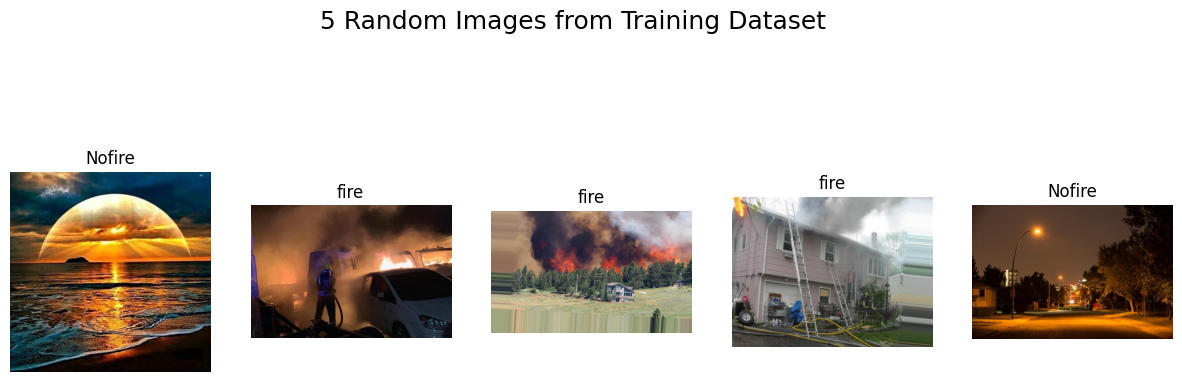

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Defining display random images any labels function for displaying random images with lables from dataset
def display_random_images_any_labels(dataset_path, subfolder, num_images=5):
    """
    Function to display randomly selected images across any labels in a specified subfolder (train/test).

    """
    # Defining Path to the subfolder (train or test)
    subfolder_path = os.path.join(dataset_path, subfolder)

    # Checking if the subfolder exists
    if not os.path.exists(subfolder_path):
        print(f"Directory not found: {subfolder_path}")
        return

    # Getting all label directories
    labels = [label for label in os.listdir(subfolder_path) if os.path.isdir(os.path.join(subfolder_path, label))]

    # Collecting all images across labels with their corresponding labels
    all_images = []
    for label in labels:
        label_path = os.path.join(subfolder_path, label)
        image_files = [os.path.join(label_path, img) for img in os.listdir(label_path) if os.path.isfile(os.path.join(label_path, img))]
        all_images.extend([(img_path, label) for img_path in image_files])

    # Randomly sampling the specified number of images
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    # Displaying the selected images
    plt.figure(figsize=(15, 5))
    for i, (img_path, label) in enumerate(selected_images):
        img = mpimg.imread(img_path)
        plt.subplot(1, len(selected_images), i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(label)
    plt.suptitle(f"5 Random Images from {subfolder.capitalize()} Dataset", fontsize=18)
    # Adjusting the spacing here
    plt.subplots_adjust(top=0.8)
    plt.show()

combined_dataset_path = '/content/combined'

# Displaying 5 random images from training
display_random_images_any_labels(combined_dataset_path, 'training', num_images=5)

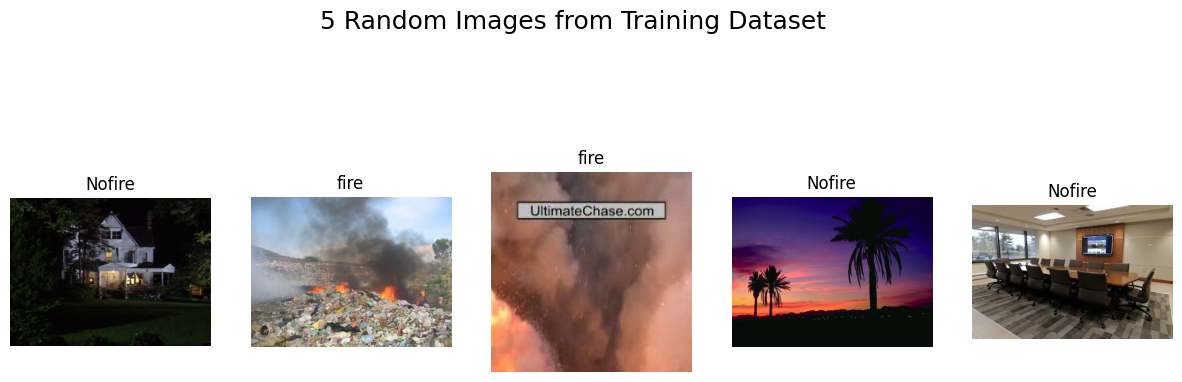

In [ ]:
# Displaying 5 random images from testing
display_random_images_any_labels(combined_dataset_path, 'training', num_images=5)

# **Task 2**

In [ ]:
! ls /content/combined/training

fire  Nofire


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm # tqdm used for visualizing the progress of loops and iterations

# Defining the directory containing the training dataset
DATADIR = '/content/combined/training'

# Defining the categories for classification
CATEGORIES = ['fire', 'Nofire']

In [ ]:
IMG_SIZE = 64

def create_training_data():
   # initializing an empty list to store the training data
    training_data = []

    for category in CATEGORIES:
        # Creating the path to the category's directory
        path = os.path.join(DATADIR,category)
        # Assigning a numerical label to the category
        class_num = CATEGORIES.index(category)

        # Iterating over each images file in the directory using tqdm for a process bar
        for img in tqdm(os.listdir(path)):
            try:
              # Reading the image using OpenCV
                img_array = cv2.imread(os.path.join(path,img))
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass
   # Returning the created training data list
    return training_data

In [ ]:
# Creating training data function to load and preprocess the training data
training_data = create_training_data()

100%|██████████| 1733/1733 [00:23<00:00, 73.59it/s]


In [ ]:
import random
# printing total number of sample in training data
print(len(training_data))

# Shuffling the training data list randomly to ensure data diversity during training
random.shuffle(training_data)
# Extracting the labels from the first 20 samples
labels = [sample[1] for sample in training_data[:20]]

# Printing the labels
print(*labels)

2943
1 0 0 0 0 1 1 1 0 1 1 1 0 1 0 1 0 0 1 0


In [ ]:
# Initializing an empty lists to store images features and labels
X = []
Y = []

for features,label in training_data:
  # Adding image features to the X list
    X.append(features)
  # Adding the corresponding labels to the Y list
    Y.append(label)

# Converting X to a numpy array and reshape it
X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 3)
X = X/255.0
X.shape[1:]
# Converting Y to a numpy array
Y = np.array(Y)
# printing the shape of a single image
print(X.shape[1:])

(64, 64, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models # from tensorflow add keras for training neural networks
from tensorflow.keras.datasets import cifar10 # import cifar-10 for image classification
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, AveragePooling2D, BatchNormalization, MaxPooling2D

# Defining a Sequential model
model = Sequential()

# Defining thwe input shape (assume X is training data)
input_shape = X.shape[1:]

# Convolutional layer-1
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(BatchNormalization()) # Batchnormalization-1
model.add(MaxPooling2D(2, 2))  # Average Pooling layer-1
#model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Dropout(0.26)) # Dropout layer-1

# Convolutional layer-2
model.add(Conv2D(filters=48, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization()) # Batchnormalization-2
model.add(MaxPooling2D(pool_size=(2, 2))) # Average Pooling layer-2
#model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Dropout(0.28)) # Dropout layer-2

# Convolutional layer-3
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization()) # Batchnormalization-3
model.add(MaxPooling2D(pool_size=(2, 2))) # Average Pooling layer-3
#model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Dropout(0.3)) # Dropout layer-3

# Flatten layer
model.add(Flatten())

# Fully-connected Dense layer
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.2)) # Dropout layer

# Activation of softmax function for multi-class classification
model.add(Dense(units=2, activation = 'sigmoid'))

# Compiling the model for evaluating model loss, optimization and matrics
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(X, Y, batch_size=32, epochs=50,validation_split=0.3)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - accuracy: 0.6842 - loss: 0.7663 - val_accuracy: 0.6002 - val_loss: 1.2124
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.7838 - loss: 0.4474 - val_accuracy: 0.6002 - val_loss: 1.1804
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.8157 - loss: 0.3958 - val_accuracy: 0.7225 - val_loss: 0.5598
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.8238 - loss: 0.3987 - val_accuracy: 0.4371 - val_loss: 1.2385
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 187ms/step - accuracy: 0.8408 - loss: 0.3378 - val_accuracy: 0.5663 - val_loss: 1.0160
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 173ms/step - accuracy: 0.8763 - loss: 0.3087 - val_accuracy: 0.6512 - val_loss: 0.6685
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 187ms/step - accuracy: 0.8834 - loss: 0.2708 - val_accuracy: 0.7610 - val_loss: 0.4604
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - accuracy: 0.8933 - loss: 0.2611 - val_accu

In [ ]:
# Saving the trained model in folder
model.save('TrainedModels/epoch50,32(0.26),48(0.28),64(0.3),16(0.2).h5')

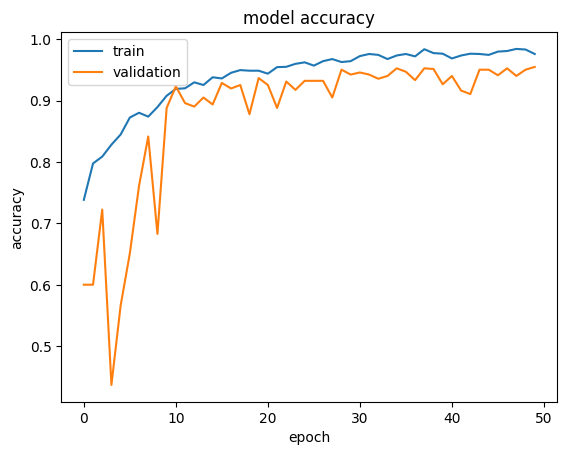

In [ ]:
from matplotlib import pyplot as plt

# Plotting the line graph of model epoch vs model accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

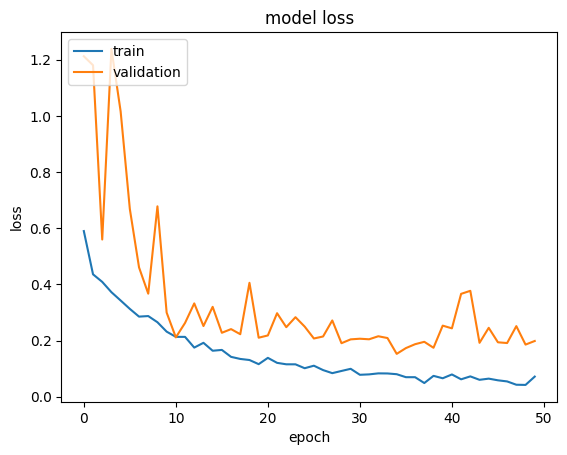

In [ ]:
# Plotting a line graph of model epoch vs model loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
from tensorflow.keras.utils import plot_model

# Loading the pre-trained model from the path
model = tf.keras.models.load_model('/content/TrainedModels/32(0.26),48(0.28),64(0.3),16(0.2).h5')

# printing the model's summary
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 29, 29, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 29, 29, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 14, 14, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 14, 14, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 12, 12, 64)     │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │        36,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,972 (312.39 KB)

 Trainable params: 79,682 (311.26 KB)

 Non-trainable params: 288 (1.12 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
! ls /content/combined/testing

fire  Nofire


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import itertools
from keras.models import load_model

# Loading the pre-trained model from the path
model=load_model('/content/TrainedModels/32(0.26),48(0.28),64(0.3),16(0.2).h5')

In [ ]:
# Defining the directory contain the testing dataset
DATADIR = r'/content/combined/testing'
# Defining the categories used for classification
CATEGORIES = ['fire', 'Nofire']

In [ ]:
def load_testing_data(DATADIR, img_size=64):
    """Loading and preprocessing testing data."""
    testing_data = []
    actual_labels = []
    for category in ['fire', 'Nofire']:
        path = os.path.join(DATADIR, category)
        class_num = ['fire', 'Nofire'].index(category)
        for img in tqdm(os.listdir(path)):
            try:
                img_array = cv2.imread(os.path.join(path, img))
                new_array = cv2.resize(img_array, (img_size, img_size))
                testing_data.append(new_array)
                actual_labels.append(class_num)
            except Exception as e:
                pass
    return np.array(testing_data), np.array(actual_labels)

In [ ]:
# Loading the testing data
test_data, actual_labels = load_testing_data(DATADIR)

# Preprocessing the testing data
test_data = test_data / 255.0

# Making predictions on the testing data
predicted_labels = (model.predict(test_data)).argmax(axis=1)
predicted_labels = predicted_labels.astype(int)  # Convert to integers

100%|██████████| 387/387 [00:04<00:00, 85.22it/s]


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step


[[607   8]
 [ 25 362]]


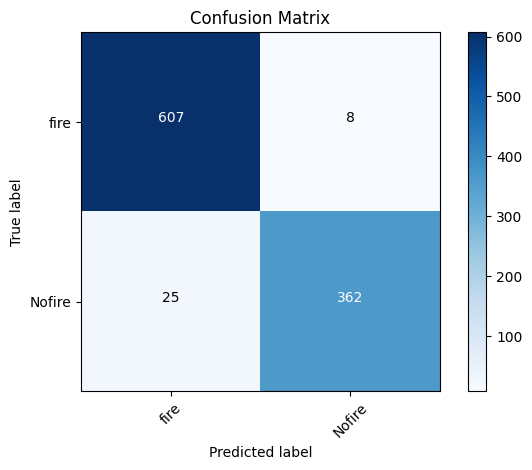

In [ ]:
def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    # Printing the confusion matrix
    print(cm)
    # Creating the plot using matplotlib
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    # Setting axis labels and layout
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm = confusion_matrix(actual_labels, predicted_labels)
# Defining labels for the plot
cm_plot_labels=['fire','Nofire']
# Plotting the confusion matrix
plot_confusion_matrix(cm, cm_plot_labels,title='Confusion Matrix')

In [ ]:
# Extracting values from the confusion matrix
tp = cm[0][0]  # True Positives: Correctly predicted fire images as fire
fp = cm[0][1]  # False Positive: Incorrectly predicted fire images as Nofire
fn = cm[1][0]  # False Negatives: Incorrectly predicted Nofire images as fire
tn = cm[1][1]  # True Negatives: Correctly predicted Nofire images as Nofire

# Printing the extracted values with labels
print("True Positive" + ' ' + str(tp))
print("False Negative" + ' ' + str(fp))
print("False Positive" + ' ' + str(fn))
print("True Negative" + ' ' + str(tn))

True Positive 607
False Negative 8
False Positive 25
True Negative 362


In [ ]:
# Calculating total parameters
total_params = model.count_params()

# Calculating Trainable Parameters
Trainable_params = sum([tf.keras.backend.count_params(p) for p in model.trainable_weights])

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {Trainable_params:,}")

# Defining recall
recall=tp/(tp+fn)
# Defining precision
precision=tp/(tp+fp)
# Defining f1 score
f1_score= 2*((precision*recall)/(precision+recall))

print(f"Recall: {recall}")
Recall = "{:.2f}".format(recall * 100) # Converting recall in percentage
print(f"Recall: {Recall} %")

print(f"Precision: {precision}")
Precision = "{:.2f}".format(precision * 100) # Converting precision in percentage
print(f"Precision: {Precision} %")

print(f"F1_Score : {f1_score}")
F1_Score = "{:.2f}".format(f1_score * 100) # Converting f1 score in percentage
print(f"F1_Score: {F1_Score} %")

Total parameters: 79,970
Trainable parameters: 79,682
Recall: 0.9604430379746836
Recall: 96.04 %
Precision: 0.9869918699186991
Precision: 98.70 %
F1_Score : 0.9735364875701685
F1_Score: 97.35 %


In [ ]:
# Defining and printing accuracy in percentage
Accuracy = model.evaluate(X, Y)[1]
Accuracy = "{:.2f}".format(Accuracy * 100)
print(f"Accuracy: {Accuracy} %")

92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9806 - loss: 0.1015
Accuracy: 98.06 %


In [ ]:
import pandas as pd

data = {"Metrics": ["Accuracy (%)","Recall (%)", "Precision (%)", "F1_Score (%)", "No. of Parameters"],
        "Combined Improved Model(Firenet + Kaggle)": [Accuracy, Recall, Precision, F1_Score, Trainable_params]}
df = pd.DataFrame(data)

# Converting numerical columns to strings formatted with 2 decimal places
for col in df.columns[1:]:
    df[col] = df[col].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else str(x))

styled_df = df.style.set_table_styles([
    {'selector': 'thead th',
     'props': [('background-color', 'lightgrey'), ('color', 'black'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'tbody td',
     'props': [('border-top', '1px solid black'), ('border-bottom', '1px solid black'),
               ('text-align', 'center'), ('padding', '5px')]},
    {'selector': 'table',
     'props': [('border-collapse', 'collapse'), ('width', '100%')]}
]).set_properties(**{'font-size': '12px', 'font-weight': 'bold'})

# Hiding index of table
styled_df = styled_df.hide(axis="index")
display(styled_df)

Metrics,Combined Improved Model(Firenet + Kaggle)
Accuracy (%),98.06
Recall (%),96.04
Precision (%),98.70
F1_Score (%),97.35
No. of Parameters,79682


# **Task 3**

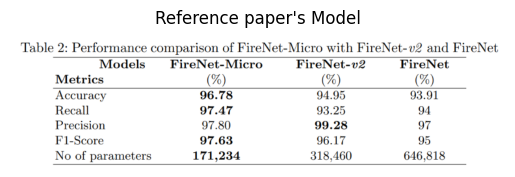

In [ ]:
import matplotlib.pyplot as plt

# Adding screenshot of reference paper's models
img = plt.imread("/content/Screenshot 2025-03-31 141410.png")
plt.imshow(img)
plt.axis("off")
plt.title("Reference paper's Model")
plt.show()

In [ ]:
import pandas as pd
from IPython.core.display import display, Markdown

# Comparing improved model with reference paper's models
data1 = {
    'Metrics': ['Accuracy (%)', 'Recall (%)', 'Precision (%)', 'F1-Score (%)', 'No. of Parameters'],
    'Combined Improved Model\n (FireNet + Kaggle)':[Accuracy, Recall, Precision, F1_Score, Trainable_params],
    'FireNet-Micro': [96.78, 97.47, 97.80, 97.63, 171234],
    'FireNet-v2': [94.95, 93.25, 99.28, 96.17, 318460],
    'FireNet': [93.91, 94, 97, 95, 646818]
}
df1 = pd.DataFrame(data1)

for col in df1.columns[1:]:
    df1[col] = df1[col].apply(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else str(x))

# Applying style in table
styled_df1 = df1.style.set_table_styles([
    {'selector': 'thead th',
     'props': [('background-color', 'lightgrey'), ('color', 'black'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'tbody td',
     'props': [('border-top', '1px solid black'), ('border-bottom', '1px solid black'),
               ('text-align', 'center'), ('padding', '5px')]},
    {'selector': 'table',
     'props': [('border-collapse', 'collapse'), ('width', '80%')]}
]).set_properties(**{'font-size': '10px', 'font-weight': 'bold'})

styled_df1 = styled_df1.hide(axis="index")
display(styled_df1)


Metrics,Combined Improved Model (FireNet + Kaggle),FireNet-Micro,FireNet-v2,FireNet
Accuracy (%),98.06,96.78,94.95,93.91
Recall (%),96.04,97.47,93.25,94.00
Precision (%),98.70,97.80,99.28,97.00
F1-Score (%),97.35,97.63,96.17,95.00
No. of Parameters,79682,171234.00,318460.00,646818.00


# **Task 4**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


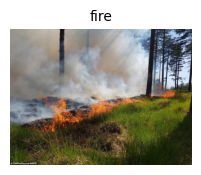

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


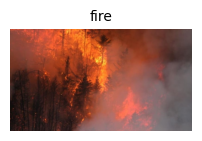

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


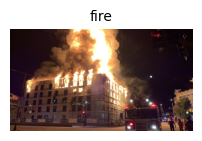

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


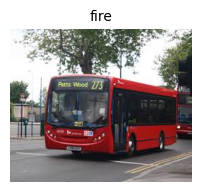

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


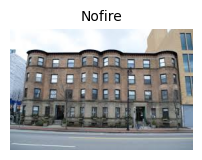

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


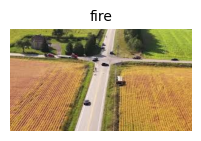

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


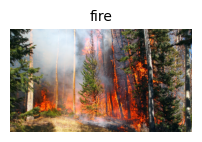

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


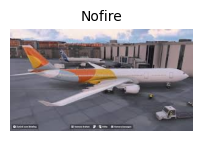

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


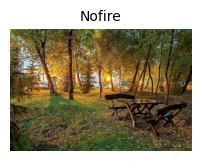

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


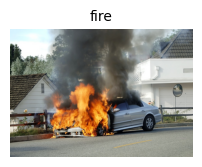

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


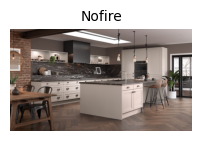

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


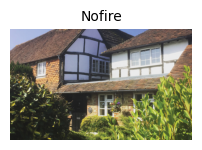

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


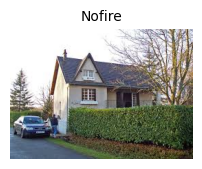

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


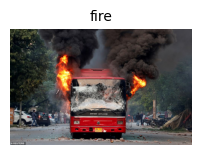

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


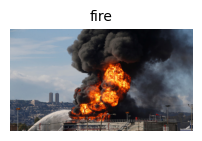

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


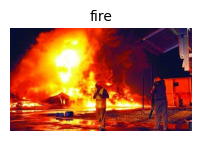

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


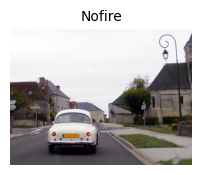

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


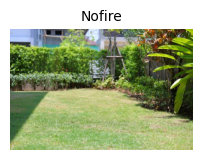

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


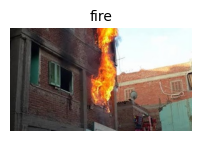

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import glob
import os
import matplotlib.pyplot as plt

# Loading the trained model
model = tf.keras.models.load_model('/content/TrainedModels/32(0.26),48(0.28),64(0.3),16(0.2).h5')

# Defining folder containing random images
image_folder = "/content/random_images"

labels = ['fire', 'Nofire']

def preprocess_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (64, 64))
    image = image.astype('float32') / 255.0
    return np.expand_dims(image, axis=0)

# Getting all image paths in the folder
image_paths = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith(('.jpg', '.png', '.jpeg'))]

for i, image_path in enumerate(image_paths[:20]):
    image = preprocess_image(image_path)
    prediction = model.predict(image)
    predicted_label = labels[np.argmax(prediction)]
    img_display = cv2.imread(image_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.subplot(4, 5, i + 1)
    plt.imshow(img_display)
    plt.title(predicted_label, fontsize=10)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## **References:**

---

Kumar, A. (2024). Firenet Detection Dataset. https://www.kaggle.com/datasets/atulyakumar98/test-dataset

ProcediaComputerScience. (2023). FireNet-v2: Improved lightweight fire detection model for real-time IoT applications. https://www.sciencedirect.com/science/article/pii/S1877050923001990

Ansari, M. (2019). FireNet: A Specialized Lightweight Fire & Smoke Detection Model for Real-Time IoT Applications. https://arxiv.org/abs/1905.11922

In [ ]:
%%shell
 jupyter nbconvert --to html /content/SE7048_J122286.ipynb

[NbConvertApp] Converting notebook /content/SE7048_J122303.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 25 image(s).
[NbConvertApp] Writing 2541082 bytes to /content/SE7048_J122303.html
